# Lagrangian-weighted current fitting

Global bound (GCQP) → GCD refinement → inferred density from the Lagrangian-weighted fit

$$\min_{\varsigma\in[0,1]^N} (\hat I_{opt}-B\varsigma)^H L^\star (\hat I_{opt}-B\varsigma),\quad B=\mathrm{diag}(\hat v_{inf}/Z_s)$$

where $L^\star$ is the quadratic part of the Lagrangian at the optimal multipliers.

In [92]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [93]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [94]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ Vinc)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

def evalObj(Ivec):
    return(-np.real(Ivec.conj().T @ Obj @ Ivec) + 2*np.real(Ivec.conj().T @ obj) + obj0)

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObj(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


In [105]:

Pdiags = np.conj(Zs) * np.ones((Ndes,1), dtype=complex)
Plist = [sp.diags(Pdiags[:,i]) for i in range(Pdiags.shape[1])]

Bmat = Obj
bVec = obj
beta = obj0


Umat = -(Zmat + Z0)/Zs
eVec = -1j * Vinc/2/np.conj(Zs)


QCQP = DenseSharedProjQCQP(
    Bmat, bVec, beta,
    Umat.conj().T, eVec,
    Plist,
    verbose=1,
)

t1 = time.time()
lags_init = np.zeros((Pdiags.shape[1],))
lags_init[0] = -1

# New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
opt_params = OptimizationHyperparameters(opttol=1e-4,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=1)

# Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 1 A matrices and Fs vectors.
Optimizer initialized with parameters:
opttol: 0.0001
gradConverge: True
min_inner_iter: 10
max_restart: 10
penalty_ratio: 0.01
penalty_reduction: 0.1
break_iter_period: 5
verbose: 1
Starting optimization with x0 = [-1.]
Outer iteration 0, penalty_ratio = 0.01, opt_fx = 12.229409615164153
iter_num: 5, prev_fx: inf, opt_fx: 12.183203106222196, opttol: 0.0001
iter_num: 10, prev_fx: 12.183203106222196, opt_fx: 12.18320310621814, opttol: 0.0001
Outer iteration 1, penalty_ratio = 0.001, opt_fx = 12.18320310621814
iter_num: 5, prev_fx: 12.183203106222196, opt_fx: 12.18320310621814, opttol: 0.0001
bound: 1.2183e+01, time: 0.04670214653015137s, Lagrange multipliers: [-0.9408364]


In [106]:
# A is the total system matrix. Here I'm checking the minimum eigenvalue to see how PSD it is.
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimum eigenvalue: {np.min(np.real(eigenvals))}")
 

Pdiags = QCQP.Proj.Pdiags


Ivec = QCQP.current_xstar
Popt = evalObj(Ivec) # optimal objective value
print(f"Optimal objective value: {Popt:.6e} W")

minimum eigenvalue: 0.011985437522414438
Optimal objective value: 1.218320e+01 W


In [107]:
from dolphindes.cvxopt.gcd import GCDHyperparameters
import copy
gcd_QCQP = copy.deepcopy(QCQP)

t = time.time()
opt_params = OptimizationHyperparameters(
    opttol=1e-6,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=0              
)

gcd_params = GCDHyperparameters(
    gcd_tol=1e-3,                 # Keep extremely tight to prevent early exit
    max_proj_cstrt_num=30,       # CRITICAL: > 390. Safely covers all complex degrees of freedom!
    max_gcd_iter_num=50,         # Increased to give GCD enough runway to generate up to 400 constraints
    gcd_iter_period=10,            # Check for convergence every 2*Nopt iterations to give GCD enough time to generate constraints and converge
    orthonormalize=True,         # Keep OFF so complex phase information isn't scrambled
    opt_params=opt_params
)
gcd_QCQP.run_gcd(gcd_params=gcd_params)
print(f'gcd optimization took time {time.time()-t}.')

Precomputed 1 A matrices and Fs vectors.
At GCD iteration #1, best dual bound found is             12.183203106226483.
min eigenvalue: 1.198544e-02
At GCD iteration #2, best dual bound found is             12.144430336869478.
min eigenvalue: 1.101319e-02
At GCD iteration #3, best dual bound found is             12.110428083191904.
min eigenvalue: 9.810845e-03
At GCD iteration #4, best dual bound found is             12.087019792841232.
min eigenvalue: 8.802409e-03
At GCD iteration #5, best dual bound found is             12.067520991847251.
min eigenvalue: 8.240366e-03
At GCD iteration #6, best dual bound found is             12.046066045421187.
min eigenvalue: 8.049540e-03
At GCD iteration #7, best dual bound found is             12.011733224868847.
min eigenvalue: 7.129409e-03
At GCD iteration #8, best dual bound found is             11.965480665306524.
min eigenvalue: 5.563271e-03
At GCD iteration #9, best dual bound found is             11.919866245395838.
min eigenvalue: 4.765463e

In [108]:
# Now let's check again for PSD of A. We don't expect the constraints to hold or to have strong duality
lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimal eigenvalue: {np.min(np.real(eigenvals))}")

minimal eigenvalue: 0.06366309382715069


In [109]:
# Now I take the solved gcd_QCQP and finetune it with BFGS if necessary.
t1 = time.time()
gcd_final_result = gcd_QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = gcd_QCQP.current_lags, opt_params = None)
print(f"bound: {gcd_final_result[0]}, time: {time.time()-t1}s")

# Let's check for PSD-ness and constraints again

lags = gcd_QCQP.current_lags
Pdiags = gcd_QCQP.Proj.Pdiags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"min eigenvalue: {np.min(np.real(eigenvals))}")

Ivec= gcd_QCQP.current_xstar

primar_obj = evalObj(Ivec)
print(f"GCD primary objective: {primar_obj}")
print(f"GCD dual bound: {gcd_QCQP.current_dual}")

bound: 10.24745983223072, time: 0.11213898658752441s
min eigenvalue: 0.06366309382288685
GCD primary objective: 10.247459833195515
GCD dual bound: 10.24745983223072


In [110]:
import matplotlib.pyplot as plt
from scipy.optimize import minimize

Iopt = gcd_QCQP.current_xstar
Lstar = Msym(gcd_QCQP._get_total_A(gcd_QCQP.current_lags))   # quadratic part of the Lagrangian
print(f"min eig L*: {np.min(np.linalg.eigvalsh(Lstar)):.3e}")

Vinf = Vinc - Z0 @ Iopt          # field incident on the material
b = Vinf / Zs                    # current of full material for this incident field

def realizedObj(dens):
    S = np.diag(dens.astype(complex))
    I = np.linalg.solve(Zs*np.eye(Ndes) + S @ Z0, S @ Vinc)
    return evalObj(I), I

# density fitting (ratio + clip)
dens_ratio = np.clip(np.real(Zs*Iopt/Vinf), 0, 1)
# pointwise current fitting
dens_point = np.clip(np.real(b.conj()*Iopt)/np.abs(b)**2, 0, 1)

min eig L*: 6.366e-02


In [ ]:
# Lagrangian-weighted fit: box-constrained QP with H = Re[B^H L B], f = -Re[B^H L Iopt]
B = np.diag(b)
H = np.real(B.conj().T @ Lstar @ B); H = 0.5*(H + H.T)
f = -np.real(B.conj().T @ Lstar @ Iopt)
c0 = np.real(Iopt.conj() @ Lstar @ Iopt)
scale = np.max(np.abs(np.diag(H)))

fun = lambda s: ((s @ H @ s) + 2*(f @ s)) / scale
jac = lambda s: 2*(H @ s + f) / scale

t1 = time.time()
res = minimize(fun, dens_point, jac=jac, method='L-BFGS-B', bounds=[(0, 1)]*Ndes,
               options={'maxiter': 20000, 'ftol': 1e-15, 'gtol': 1e-12})
dens_lag = res.x
print(f"L-BFGS-B: {res.message}, iters {res.nit}, time {time.time()-t1:.2f}s")


def lagResidual(dens):
    r = Iopt - b*dens
    return np.real(r.conj() @ Lstar @ r)

print(f"dual bound: {gcd_QCQP.current_dual:.6e} W, full plate: {Pfull:.6e} W")
results = {}
for name, d in [('ratio clip', dens_ratio), ('pointwise current', dens_point), ('Lagrangian-weighted', dens_lag)]:
    P, _ = realizedObj(d)
    results[name] = d
    print(f"{name:22s} objective {P:.6e} W | L*-residual {lagResidual(d):.3e} | mean density {d.mean():.3f}")

L-BFGS-B: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH, iters 188, time 0.00s
dual bound: 1.024746e+01 W, full plate: 1.010821e+01 W
ratio clip             objective 7.920752e-07 W | L*-residual 3.723e+01 | mean density 0.000
pointwise current      objective 7.920752e-07 W | L*-residual 3.723e+01 | mean density 0.000
Lagrangian-weighted    objective 1.513677e-06 W | L*-residual 1.006e+01 | mean density 0.000


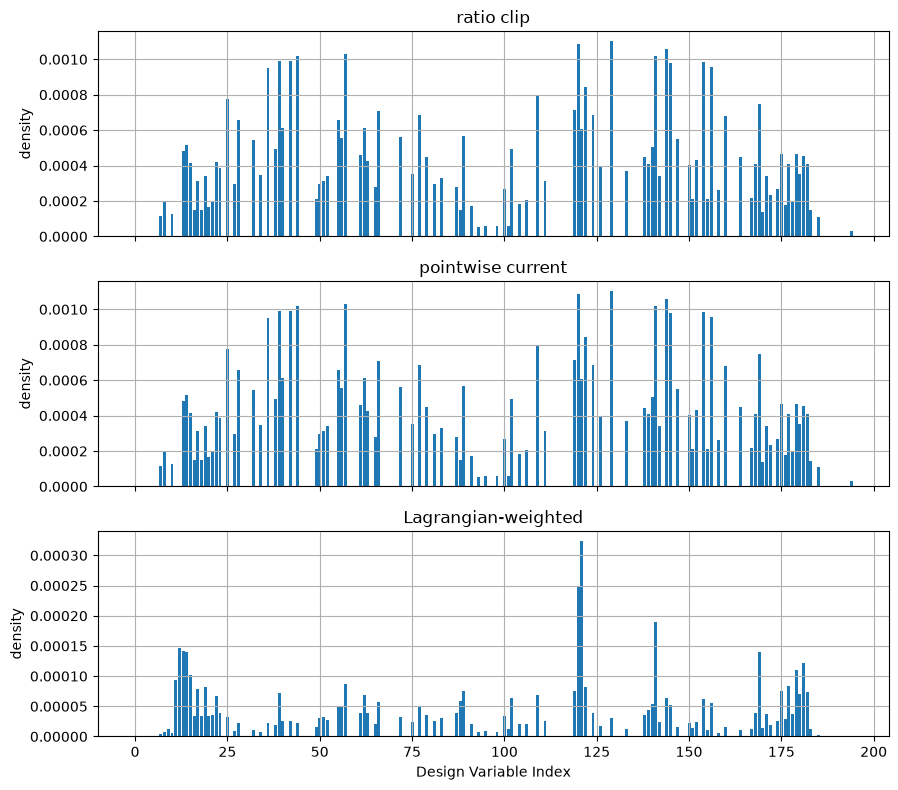

In [112]:
fig, ax = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for a_, (name, d) in zip(ax, results.items()):
    a_.bar(np.arange(Ndes), d)
    a_.set_ylabel('density'); a_.set_title(name); a_.grid(True)
ax[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()

best threshold 0.05: objective 0.000000e+00 W


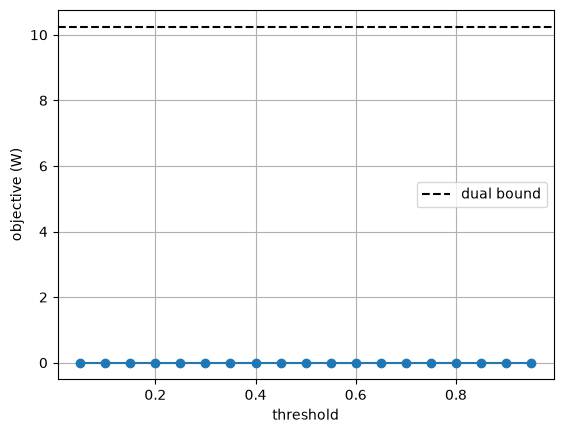

In [113]:
# binary rounding of the Lagrangian-weighted design: threshold sweep
ths = np.linspace(0.05, 0.95, 19)
Pbin = [realizedObj((dens_lag > t).astype(float))[0] for t in ths]
tbest = ths[int(np.argmax(Pbin))]
print(f"best threshold {tbest:.2f}: objective {max(Pbin):.6e} W")
plt.plot(ths, Pbin, 'o-'); plt.axhline(gcd_QCQP.current_dual, ls='--', c='k', label='dual bound')
plt.xlabel('threshold'); plt.ylabel('objective (W)'); plt.legend(); plt.grid(True); plt.show()
np.savetxt('lagrangian_fit_density.txt', dens_lag, delimiter=',')